# Classifier Results Analysis
This notebook analyzes results from the binary classifier and helps identify trends or limitations in the dataset.

In [63]:
from astropy.table import Table, vstack, join, unique
from SGA.ssl import load_ssl_embeddings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [11]:
def load_combined_ssl_data(ssl_dir='/global/cfs/cdirs/desicollab/users/ioannis/SGA/2025/ssl'):
    south = load_ssl_embeddings('dr11-south', ssl_dir)
    north = load_ssl_embeddings('dr11-north', ssl_dir)
    south['region'] = 'dr11-south'   # tag before combining, so downstream
    north['region'] = 'dr11-north'   # region-specific lookups (cutout_index,
    return vstack([south, north])    # viewer links) stay correct per-row

main_data = load_combined_ssl_data()

INFO:SGA.py:363:_read_catalog: Read 363,633/395,435 GROUP_PRIMARY objects from /dvs_ro/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/sample/SGA2025-beta-v1.6-dr11-south.fits
INFO:SGA.py:370:_read_catalog: Selecting 363,633/363,633 objects in region=dr11-south
INFO:ssl.py:323:load_ssl_embeddings: load_ssl_embeddings: 363,607 objects from /global/cfs/cdirs/desicollab/users/ioannis/SGA/2025/ssl/ssl-embeddings-dr11-south.hdf5
INFO:SGA.py:363:_read_catalog: Read 82,093/90,504 GROUP_PRIMARY objects from /dvs_ro/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/sample/SGA2025-beta-v1.6-dr11-north.fits
INFO:SGA.py:370:_read_catalog: Selecting 82,093/82,093 objects in region=dr11-north
INFO:ssl.py:323:load_ssl_embeddings: load_ssl_embeddings: 82,086 objects from /global/cfs/cdirs/desicollab/users/ioannis/SGA/2025/ssl/ssl-embeddings-dr11-north.hdf5


In [12]:
mask = ["SGAID", "RA", "DEC", "D26", "BA", "BANDS", "GROUP_MULT", "PA"]
for col in main_data.colnames:  
    if col not in mask:
        main_data.remove_column(col)
main_data

SGAID,GROUP_MULT,BANDS,RA,DEC,D26,BA,PA
int64,int16,str4,float64,float64,float64,float32,float32
1,1,griz,0.06620700222837696,-72.18653561329143,0.5925561189651489,0.64823765,166.15268
3,1,griz,0.11464875176680563,-7.8819411179990615,1.1449767351150513,0.64245033,135.01004
10,1,griz,0.40810451791720975,-83.23644254540766,0.951040506362915,0.5886185,79.648445
14,1,griz,0.705979349536371,-66.18656573373114,1.219663381576538,0.40420878,131.70578
19,1,griz,0.9304725672570379,-83.41098934977177,0.8343076109886169,0.47635624,162.49779
25,1,grz,1.4456801022423116,28.26973615597305,0.4985831081867218,0.9135399,67.70538
36,1,grz,1.581410063435992,20.202928782768744,0.6914367079734802,0.86070734,113.77838
38,1,griz,1.634430357430443,-18.03098513179292,0.9548138976097107,0.5486742,18.674854
40,2,griz,1.7607630487696069,-42.188740880205955,0.5482754707336426,0.7953559,69.20897


In [67]:
complete = Table.read("/pscratch/sd/q/qshimp/Sorter/binary_classifier/sga2025_sample_test3/final_results/final_catalog.csv")
mask = ["Embeddings", "UMAP_Coordinates", "Main_Type"]
for col in mask:
   complete.remove_column(col)
complete.rename_column("targetid", "SGAID")

mask = np.isin(main_data["SGAID"], complete["SGAID"])

filtered_data = main_data[mask]
classified_data = join(filtered_data, complete["SGAID", "Galaxy_Type"], keys='SGAID', join_type='left')
dedup = unique(classified_data, keys='SGAID')
classified_data

SGAID,GROUP_MULT,BANDS,RA,DEC,D26,BA,PA,Galaxy_Type
int64,int16,str4,float64,float64,float64,float32,float32,str10
1,1,griz,0.06620700222837696,-72.18653561329143,0.5925561189651489,0.64823765,166.15268,Elliptical
3,1,griz,0.11464875176680563,-7.8819411179990615,1.1449767351150513,0.64245033,135.01004,Irregular
10,1,griz,0.40810451791720975,-83.23644254540766,0.951040506362915,0.5886185,79.648445,Irregular
14,1,griz,0.705979349536371,-66.18656573373114,1.219663381576538,0.40420878,131.70578,Spiral
19,1,griz,0.9304725672570379,-83.41098934977177,0.8343076109886169,0.47635624,162.49779,Irregular
25,1,grz,1.4456801022423116,28.26973615597305,0.4985831081867218,0.9135399,67.70538,Spiral
36,1,grz,1.581410063435992,20.202928782768744,0.6914367079734802,0.86070734,113.77838,Lenticular
38,1,griz,1.634430357430443,-18.03098513179292,0.9548138976097107,0.5486742,18.674854,Lenticular
40,2,griz,1.7607630487696069,-42.188740880205955,0.5482754707336426,0.7953559,69.20897,Elliptical


In [69]:
print(len(classified_data))
print(len(dedup)) # How did that happen - there are 442412 galaxies in 

469882
428822


In [139]:
# Attribute testing
# "D26", "BA", "BANDS", "GROUP_MULT", "PA"
attribute = "D26"
n_shown = 10

dedup.sort(attribute, reverse=True)

extrema = {
    "max": dedup[:n_shown],
    "min": dedup[-n_shown:]
}

print(f"Sort by {attribute}")

for name, rows in extrema.items():
    print(f"\n{name}")
    print("------------------")

    for row in rows:
        sga_id = row["SGAID"]
        gal_type = row["Galaxy_Type"]
        attr_value = row[attribute]

        print(f"{int(sga_id)} | {attribute}: {attr_value} | {str(gal_type).lower()}")


Sort by D26

max
------------------
4931495 | D26: 77.60862731933594 | elliptical
5053771 | D26: 47.7599983215332 | lenticular
4971304 | D26: 43.51447296142578 | elliptical
5053794 | D26: 39.81000518798828 | elliptical
5053885 | D26: 38.939998626708984 | elliptical
3152260 | D26: 36.132041931152344 | irregular
5001572 | D26: 28.840003967285156 | elliptical
5054127 | D26: 28.77012825012207 | elliptical
4688731 | D26: 28.459999084472656 | elliptical
5022052 | D26: 27.0 | lenticular

min
------------------
5053938 | D26: 0.14327068626880646 | lenticular
5054115 | D26: 0.14000003039836884 | elliptical
5054211 | D26: 0.13989043235778809 | spiral
5054009 | D26: 0.13034620881080627 | spiral
5054235 | D26: 0.128189355134964 | spiral
5054113 | D26: 0.10000003129243851 | elliptical
5053877 | D26: 0.06323281675577164 | elliptical
5054141 | D26: 0.05780617892742157 | spiral
5053949 | D26: 0.05424872785806656 | irregular
5056388 | D26: 0.05155060440301895 | irregular


In [71]:
dedup

SGAID,GROUP_MULT,BANDS,RA,DEC,D26,BA,PA,Galaxy_Type
int64,int16,str4,float64,float64,float64,float32,float32,str10
5031613,34,griz,194.89878007206184,27.959294216308326,8.199092864990234,0.8573962,22.28119,Elliptical
3139342,14,griz,95.36464584942706,-64.99278210346921,5.263981342315674,0.6974831,152.24687,Lenticular
3141920,14,griz,159.1486492446521,-27.51827820429174,4.924078941345215,0.5200197,79.751785,Lenticular
4970919,13,griz,21.49630380847705,-1.3402497830494708,5.4762187004089355,0.5939843,73.004105,Elliptical
4879290,13,grz,153.4604947310872,38.76488079825024,4.8742899894714355,0.8531936,163.58865,Elliptical
4904732,13,griz,230.77198620420342,8.60928181428642,6.126055717468262,0.4823527,24.08744,Elliptical
4947004,11,griz,87.1598145872559,-25.477806516175704,3.9291834831237793,0.72244483,71.51245,Spiral
3151990,11,griz,354.6224410177196,27.031496323490888,4.788719654083252,0.74343145,37.758488,Spiral
3143646,11,griz,192.51626410146352,-41.381969005782054,7.4841837882995605,0.6753675,117.856735,Lenticular


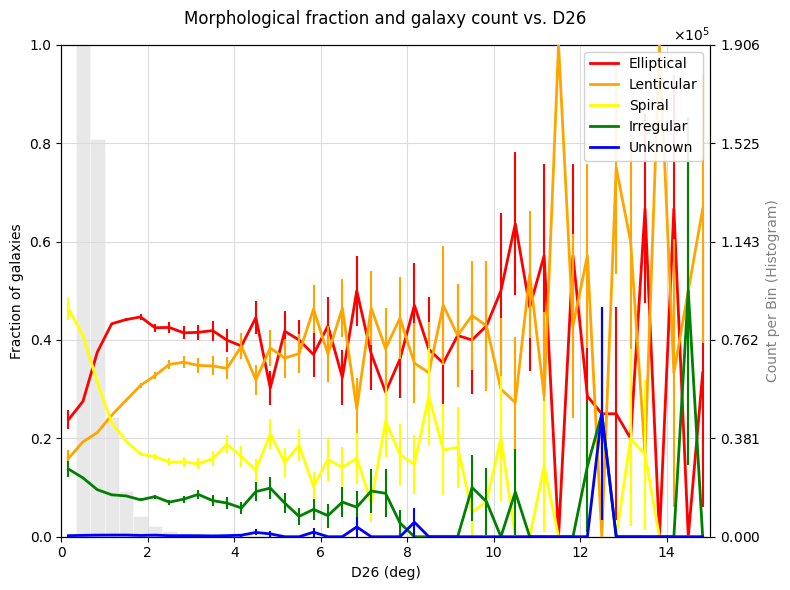

In [142]:
# Diameter values
classes = ['Elliptical', 'Lenticular', 'Spiral', 'Irregular', 'Unknown']

data_to_plot = np.asarray(dedup[attribute])
hist_data = dedup[attribute]

#a = np.min(dedup[attribute])
a = 0
#b = np.max(dedup[attribute])
b = 15
# Define unified bins for BOTH the fractions and the histogram
n_bins = 45
edges = np.linspace(a, b, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

# 1. Initialize a single figure and the primary axes (for fractions)
fig, ax1 = plt.subplots(figsize=(8, 6))

# 2. Create a secondary Y-axis for the histogram that shares the same X-axis
ax2 = ax1.twinx()

# --- BACKGROUND: Galaxy Count Histogram ---
# Crucial Fix: We now pass the exact same 'edges' array to the histogram
counts, bin_edges = np.histogram(hist_data, bins=edges)
ax2.hist(hist_data, bins=edges, color='lightgray', alpha=0.5, edgecolor='white', linewidth=0.5, zorder=1)
ax2.set_ylabel("Count per Bin (Histogram)", color='gray')

# --- FOREGROUND: Morphological Fractions ---
colors = ['red', 'orange', 'yellow', 'green', 'blue']

for color_idx, c in enumerate(classes):
    fractions = []
    errors = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = (data_to_plot >= lo) & (data_to_plot < hi)
        total = np.sum(in_bin)

        if total == 0:
            fractions.append(np.nan)
            errors.append(np.nan)
        else:
            frac = np.sum(in_bin & (dedup['Galaxy_Type'] == c)) / total
            error = np.sqrt(frac * (1 - frac) / total)
            fractions.append(frac)
            errors.append(error)
            
    # Plot on the primary axes (ax1)
    ax1.plot(centers, fractions, label=c, color=colors[color_idx], linewidth=2, zorder=3)
    ax1.errorbar(centers, fractions, yerr=errors, fmt='none', ecolor=colors[color_idx], zorder=3)

ax1.set_xlabel(f"{attribute} (deg)")
ax1.set_ylabel("Fraction of galaxies")
ax1.set_title(f"Morphological fraction and galaxy count vs. {attribute}", pad=15)

ax1.set_ylim(0, 1.0)
ax1.set_yticks(np.linspace(0, 1.0, 6))

max_count = np.max(counts)
ax2_max = int(np.ceil(max_count / 5.0) * 5)
ax2.set_ylim(0, ax2_max)
ax2.set_yticks(np.linspace(0, ax2_max, 6))

# Handle gridlines 
ax1.grid(True, which='major', color='gainsboro', linestyle='-', zorder=0)
ax2.grid(False) 

# Fix scientific notation overlapping 
ax2.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0, 3))

# Layering layout fixes
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# --- GLOBAL SETTINGS ---
ax1.set_xlim(a, b)
ax1.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()
